# Week 1 — EDA & Data Understanding (DAIGT-V2)

**Goal:** understand the real dataset (the DAIGT-V2 compilation) before doing anything else &mdash; schema, class balance, which LLMs generated which essays, how prompts are grouped, essay length, and duplicate risk. This directly feeds the dedup and leakage-safe split work that follows.

See `Archive/baseline_flawed.ipynb` for the original 282-sample, single-generator baseline this replaces, and why its 100% accuracy wasn't a real result.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv('../data/raw/train.csv')

## Schema and first look

Five columns: `text`, `label` (0 = human, 1 = AI), `prompt_name`, `source` (which generator produced it), and `RDizzl3_seven` (a flag for the seven prompts used in the original Kaggle competition's test set). `describe()` only summarizes `label` since it's the only numeric column &mdash; its mean (~0.39) is a first hint at the class balance, confirmed properly below.

In [3]:
df.head()

,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False


In [4]:
df.shape

(44868, 5)

In [5]:
df.dtypes

text             object
label             int64
prompt_name      object
source           object
RDizzl3_seven      bool
dtype: object

In [6]:
df.describe()

,label
count,44868.000000
mean,0.389966
std,0.487748
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


## Data quality checks

No missing values anywhere, and `df.duplicated()` finds zero exact-duplicate rows &mdash; no essay is a byte-for-byte copy of another. That's a good sign, but it only rules out *exact* copies; near-duplicates (light paraphrases, minor edits) won't show up here and need a separate check (MinHash/LSH &mdash; see the dedup notebook).

In [7]:
df.isna().sum()

text             0
label            0
prompt_name      0
source           0
RDizzl3_seven    0
dtype: int64

In [8]:
df.loc[df.duplicated()]

,text,label,prompt_name,source,RDizzl3_seven


In [9]:
df.columns

Index(['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven'], dtype='object')

## Generator distribution (`source`)

17 distinct sources: `persuade_corpus` (the human essay pool), the original competition's `train_essays` folded in as its own source, and 15 different AI generators spanning GPT-3.5 (`chat_gpt_moth`), GPT-4 (`radekgpt4`), Claude (`darragh_claude_v6`/`v7`), PaLM, Cohere, Llama 2 at multiple sizes, Mistral 7B, and Falcon-180B. This diversity is exactly what makes DAIGT-V2 usable &mdash; the old dataset's 100% accuracy came from a single generation batch acting as a fingerprint, not real detection.

In [10]:
df.source.value_counts()

source
persuade_corpus                       25996
mistral7binstruct_v2                   2421
chat_gpt_moth                          2421
llama2_chat                            2421
mistral7binstruct_v1                   2421
kingki19_palm                          1384
train_essays                           1378
llama_70b_v1                           1172
falcon_180b_v1                         1055
darragh_claude_v6                      1000
darragh_claude_v7                      1000
radek_500                               500
NousResearch/Llama-2-7b-chat-hf         400
mistralai/Mistral-7B-Instruct-v0.1      400
cohere-command                          350
palm-text-bison1                        349
radekgpt4                               200
Name: count, dtype: int64

## Class balance (`label`)

27,371 human vs 17,497 AI &mdash; roughly 61/39, not the artificially balanced 50/50 of the old dataset. Splits should stratify on this ratio rather than force-balancing it away.

In [11]:
df.label.value_counts()

label
0    27371
1    17497
Name: count, dtype: int64

## Prompt distribution (`prompt_name`)

15 distinct essay topics, ranging from 1,583 rows ("Phones and driving") to 5,554 ("Distance learning"). Worth checking whether every prompt has *both* human and AI essays ("prompt overlap") &mdash; otherwise a model could shortcut by learning topic vocabulary instead of genuine AI-vs-human style. Not yet checked in this notebook; see Key Takeaways at the end.

In [12]:
df.prompt_name.value_counts()

prompt_name
Distance learning                        5554
Seeking multiple opinions                5176
Car-free cities                          4717
Does the electoral college work?         4434
Facial action coding system              3084
Mandatory extracurricular activities     3077
Summer projects                          2701
Driverless cars                          2250
Exploring Venus                          2176
Cell phones at school                    2119
Grades for extracurricular activities    2116
Community service                        2092
"A Cowboy Who Rode the Waves"            1896
The Face on Mars                         1893
Phones and driving                       1583
Name: count, dtype: int64

## The `RDizzl3_seven` flag

A boolean marking whether a row's prompt is one of the seven "official" prompts the Kaggle competition organizers tested on, versus one of the eight extra prompts contributors added. The groupby below confirms it's a clean per-prompt flag &mdash; every essay under the same `prompt_name` shares the same `RDizzl3_seven` value, so it's really a prompt-level tag, not row-level noise.

In [13]:
df.RDizzl3_seven.value_counts()

RDizzl3_seven
False    24418
True     20450
Name: count, dtype: int64

In [20]:
df.groupby('prompt_name')['RDizzl3_seven'].mean()

prompt_name
"A Cowboy Who Rode the Waves"            1.0
Car-free cities                          1.0
Cell phones at school                    0.0
Community service                        0.0
Distance learning                        0.0
Does the electoral college work?         1.0
Driverless cars                          1.0
Exploring Venus                          1.0
Facial action coding system              1.0
Grades for extracurricular activities    0.0
Mandatory extracurricular activities     0.0
Phones and driving                       0.0
Seeking multiple opinions                0.0
Summer projects                          0.0
The Face on Mars                         1.0
Name: RDizzl3_seven, dtype: float64

## Is every `source` a clean human/AI label?

Checking that `label` doesn't vary within a `source` &mdash; if a source mixed both classes, it wouldn't be safe to use as a grouping key for a held-out-generator split later. `train_essays` is the one exception (`nunique == 2`): it's literally the original Kaggle `train_essays.csv` folded into DAIGT-V2 as its own source tag, carrying over the same 3 oddly-labeled rows from that original file. Every other source is purely human (`persuade_corpus`) or purely one AI generator (mean = 1.0), which makes `source` a clean, usable grouping key.

In [19]:
df.groupby('source')['label'].agg(['nunique', 'mean', 'count'])

,nunique,mean,count
source,,,
NousResearch/Llama-2-7b-chat-hf,1,1.000000,400
chat_gpt_moth,1,1.000000,2421
cohere-command,1,1.000000,350
darragh_claude_v6,1,1.000000,1000
darragh_claude_v7,1,1.000000,1000
falcon_180b_v1,1,1.000000,1055
kingki19_palm,1,1.000000,1384
llama2_chat,1,1.000000,2421
llama_70b_v1,1,1.000000,1172


Same balance as a proportion, for the write-up:

In [22]:
df['label'].value_counts(normalize=True)

label
0    0.610034
1    0.389966
Name: proportion, dtype: float64

## Essay length by label

Word count per essay. Note: the calculation right below isn't assigned to anything &mdash; the next cell (`df['n_words'] = ...`) is the one that actually sticks and gets used from here on.

In [23]:
df['text'].str.split().str.len()

0        379
1        366
2        178
3        212
4        332
        ... 
44863    382
44864    351
44865    275
44866    254
44867    399
Name: text, Length: 44868, dtype: int64

In [26]:
df['n_words'] = df['text'].str.split().str.len()

In [27]:
df.head()

,text,label,prompt_name,source,RDizzl3_seven,n_words
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False,379
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False,366
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False,178
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False,212
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False,332


In [28]:
df.groupby('label')['n_words'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,27371.0,418.283146,189.285918,143.0,274.0,383.0,519.0,1656.0
1,17497.0,329.398983,94.256529,4.0,274.0,328.0,386.0,818.0


<Axes: xlabel='n_words', ylabel='Count'>

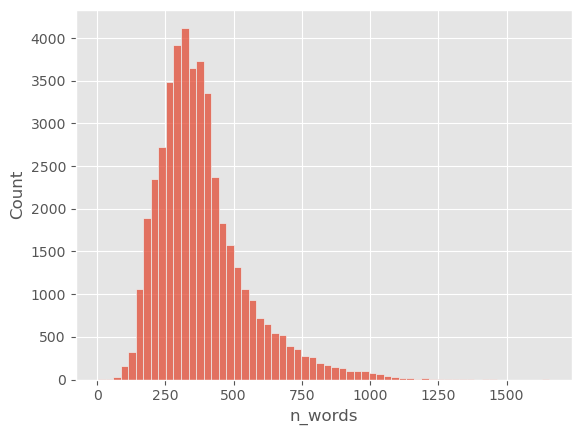

In [31]:
sns.histplot(data=df , x='n_words', bins=60)

## Very short / degenerate essays

Both of the two essays under 20 words are AI-generated (`label == 1`) &mdash; one is a corrupted, stuttering generation, the other looks like it got cut off after a single sentence. Neither is a real essay; these are generation artifacts, not genuine short AI writing. Worth dropping both (`df = df[df['n_words'] >= 20]`) before the dedup/split notebook &mdash; only 2 rows out of 44,868, no meaningful data loss, and it's a cleaner, documentable decision than leaving known-garbage rows in.

In [32]:
df[df['n_words'] < 20]

,text,label,prompt_name,source,RDizzl3_seven,n_words
36926,Ummm... H-hi Mr./Ms. S-s-s-s-s-s-s-s-s-s-s-s-s...,1,Seeking multiple opinions,llama2_chat,False,4
41204,"In recent years, there has been a growing trend",1,Distance learning,mistralai/Mistral-7B-Instruct-v0.1,False,9


## Reading actual text samples

Numbers only go so far &mdash; reading full essays side by side is how you catch things no summary statistic shows: a generator that always opens the same way, leftover artifacts, inconsistent formatting. `display.max_colwidth` is reset to `None` first so pandas stops truncating long text to 50 characters.

In [37]:
pd.set_option('display.max_colwidth', None)

In [38]:
df[df['source']=='chat_gpt_moth']['text'].sample(2, random_state=1)

29824                                                                                                                                                                                                                                                                                           Deciding on a career can be a difficult and time-consuming process, and for students in high school, it presents a unique challenge. On one hand, making career decisions in high school can be beneficial for students who already have a specific interest or goal in mind. High school provides ample opportunities to explore potential career paths and test out different areas of interest. On the other hand, requiring students to pick a career right when they enter high school can be detrimental to their development. It can be stressful for students who don’t have the resources to effectively explore their options and who lack adequate information to make a meaningful decision.\n\nVarious methods can help stu

In [39]:
df[df['source']=='persuade_corpus']['text'].sample(2, random_state=1)

8035     The author supports the idea that studying Venus is a worthy pursuit despite the dangers by explaining and reasoning about Venus. Venus is a simple to see from the distant. Each previous mission was unmanned. Venus is a challenging planet and no spaceship has touched down on Venus in more than three decades. I believe that Venus is a worthy pursuit despite of dangers because it's a challenging place to examine more closely, has different speeds, and the atmosphere and heat.\n\nVenus is sometimes called the "Evening Star," is one of the brightest points of the night sky, making it simple for even an amateur stargazer to spot. Venus is the second planet from our sun. The nickname is misleading since Venus is actually a planet. According to Paragraph 1 it says that, "While Venus is simple to see from the distant but safe vantage point of Earth, it has proved a very challenging place to examine more closely." This quote states that Venus is danger and challenging to observe.\n\nVe

## Key takeaways for the dedup & split notebooks

- Stratify splits on `label` at ~61/39 rather than force-balancing to 50/50.
- Group-split on `source` for a held-out-generator robustness slice &mdash; confirmed clean (single-label) except `train_essays`.
- `prompt_name` / `RDizzl3_seven` give a second, independent grouping axis for a held-out-topic slice.
- Still to check: whether every prompt has both human and AI essays ("prompt overlap") &mdash; not yet verified in this notebook.
- No exact duplicates, but near-duplicate check (MinHash/LSH) is still required before finalizing the split.
- Drop the 2 degenerate short essays (both AI generation artifacts) before moving on.
- Essay length differs systematically by label (AI essays shorter, more tightly clustered) &mdash; a known surface signal to note in the data card, not silently fix.